In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.interpolate import RegularGridInterpolator
import seaborn as sns
from mpl_toolkits.axes_grid1.inset_locator import mark_inset

from itertools import product
import matplotlib.colors as mcolors
from wrf_io import postproc

In [35]:
fontsize = 24
plt.rcParams['xtick.labelsize'] = 20 
plt.rcParams['ytick.labelsize'] = 20 

plt.rcParams.update({
    'text.usetex': True,
    'text.latex.preamble': r'\usepackage{amsfonts}'
})

# Training

In [153]:
casenames = np.load('/scratch/09909/smata/induction_modeling/gaussian_process/10MW/train_data/processedData/sweep_names.npy')
U_inf     = np.load('/scratch/09909/smata/induction_modeling/gaussian_process/10MW/train_data/processedData/U_inf.npy')
dir_inf   = np.load('/scratch/09909/smata/induction_modeling/gaussian_process/10MW/train_data/processedData/dir_inf.npy')
U_disk    = np.load('/scratch/09909/smata/induction_modeling/gaussian_process/10MW/train_data/processedData/U_disk.npy')
dir_disk  = np.load('/scratch/09909/smata/induction_modeling/gaussian_process/10MW/train_data/processedData/dir_disk.npy')
Uhub      = np.load('/scratch/09909/smata/induction_modeling/gaussian_process/10MW/train_data/processedData/Uhub.npy')
wrf_omg   = np.load('/scratch/09909/smata/induction_modeling/gaussian_process/10MW/train_data/processedData/wrf_omg.npy')
pitch     = np.load('/scratch/09909/smata/induction_modeling/gaussian_process/10MW/train_data/processedData/pitch.npy')

wrf_tsr = 2 * np.pi / 60 * 99.5 / 7 * wrf_omg

In [154]:
indices = [14,15,16,17,18,19,20]

In [155]:
Nelm = 30
Nsct = 160

In [156]:
veers_tr = np.array([-0.2,-0.13,-0.067,0.0,0.067,0.13,0.2])

In [157]:
from MITRotor import BEM, BEMGeometry, IEA10MW, NoTipLoss, WRFLESAerodynamics, NoTangentialInduction, ConstantInduction_GP_CTprime

In [159]:
rotor = IEA10MW()

gpr_tr_ind = np.zeros_like(indices, dtype='float')
gpr_tr_cot = np.zeros_like(indices, dtype='float')
gpr_tr_thr = np.zeros_like(indices, dtype='float')
gpr_tr_cop = np.zeros_like(indices, dtype='float')
gpr_tr_pow = np.zeros_like(indices, dtype='float')
iters   = np.zeros_like(indices, dtype='float')

for count in range(len(gpr_tr_ind)):

    index = indices[count]

    bem = BEM(rotor=rotor, geometry=BEMGeometry(Nr=Nelm,Ntheta=Nsct,R=rotor.R, Rhub = rotor.hub_radius), aerodynamic_model=WRFLESAerodynamics(), tiploss_model=NoTipLoss(), momentum_model=ConstantInduction_GP_CTprime(veer = veers_tr[count]), tangential_induction_model=NoTangentialInduction())

    sol = bem(pitch[index], wrf_tsr[index], 0, v_inf = Uhub[index], U = U_inf[:,:,index]/Uhub[index], wdir=dir_inf[:,:,index], veer = veers_tr[count])

    gpr_tr_cot[count] = sol.Ct()
    gpr_tr_thr[count] = sol.thrust()/1e3
    gpr_tr_pow[count] = sol.power()/1e6
    gpr_tr_cop[count] = sol.Cp()
    gpr_tr_ind[count] = sol.a()
    iters[count]   = sol.niter
    
iters

array([3., 3., 4., 4., 3., 3., 3.])

In [131]:
from MITRotor import BEM, BEMGeometry, IEA10MW, NoTipLoss, WRFLESAerodynamics, NoTangentialInduction, ConstantInduction

In [132]:
# LES Baseline

rotor = IEA10MW()

base_les_tr_ind = np.zeros_like(indices, dtype='float')
base_les_tr_cot = np.zeros_like(indices, dtype='float')
base_les_tr_thr = np.zeros_like(indices, dtype='float')
base_les_tr_cop = np.zeros_like(indices, dtype='float')
base_les_tr_pow = np.zeros_like(indices, dtype='float')
iters   = np.zeros_like(indices, dtype='float')

for count in range(len(base_les_tr_ind)):

    print(f'case: {count}')

    index = indices[count]

    bem = BEM(rotor=rotor, geometry=BEMGeometry(Nr=Nelm,Ntheta=Nsct,R=rotor.R, Rhub = rotor.hub_radius), aerodynamic_model=WRFLESAerodynamics(), tiploss_model=NoTipLoss(), momentum_model=ConstantInduction(a=0), tangential_induction_model=NoTangentialInduction())

    sol = bem(pitch[index], wrf_tsr[index], 0, v_inf = Uhub[index], U = U_disk[:,:,index]/Uhub[index], wdir=dir_disk[:,:,index], veer = veers_tr[count])

    base_les_tr_cot[count] = sol.Ct()
    base_les_tr_thr[count] = sol.thrust()/1e3
    base_les_tr_pow[count] = sol.power()/1e6
    base_les_tr_cop[count] = sol.Cp()
    base_les_tr_ind[count] = sol.a()
    iters[count]   = sol.niter

iters

case: 0
case: 1
case: 2
case: 3
case: 4
case: 5
case: 6


array([6., 6., 6., 6., 6., 6., 6.])

In [133]:
gpr_tr_pow

array([3.13803364, 3.16944968, 3.18556444, 3.17988168, 3.14977884,
       3.09684762, 3.02716094])

In [147]:
gpr_te_pow

array([3.13597234, 3.16820628, 3.18485207, 3.17988168, 3.15050721,
       3.09814333, 3.0293264 ])

In [134]:
base_les_tr_pow

array([3.124939  , 3.16526111, 3.1846372 , 3.18019511, 3.14429891,
       3.08609752, 3.00277002])

# Validate

In [135]:
casenames = np.load('/scratch/09909/smata/induction_modeling/gaussian_process/10MW/validation_data/processedData/sweep_names.npy')
U_inf     = np.load('/scratch/09909/smata/induction_modeling/gaussian_process/10MW/validation_data/processedData/U_inf.npy')
dir_inf   = np.load('/scratch/09909/smata/induction_modeling/gaussian_process/10MW/validation_data/processedData/dir_inf.npy')
U_disk    = np.load('/scratch/09909/smata/induction_modeling/gaussian_process/10MW/validation_data/processedData/U_disk.npy')
dir_disk  = np.load('/scratch/09909/smata/induction_modeling/gaussian_process/10MW/validation_data/processedData/dir_disk.npy')
Uhub      = np.load('/scratch/09909/smata/induction_modeling/gaussian_process/10MW/validation_data/processedData/Uhub.npy')
wrf_omg   = np.load('/scratch/09909/smata/induction_modeling/gaussian_process/10MW/validation_data/processedData/wrf_omg.npy')
pitch     = np.load('/scratch/09909/smata/induction_modeling/gaussian_process/10MW/validation_data/processedData/pitch.npy')

wrf_tsr = 2 * np.pi / 60 * 99.5 / 7 * wrf_omg

In [136]:
indices = [7,8,9,10,11,12,13]

In [137]:
veers_va = np.array([-0.18,-0.12,-0.06,0.0,0.06,0.12,0.18])

In [160]:
rotor = IEA10MW()

gpr_va_ind = np.zeros_like(indices, dtype='float')
gpr_va_cot = np.zeros_like(indices, dtype='float')
gpr_va_thr = np.zeros_like(indices, dtype='float')
gpr_va_cop = np.zeros_like(indices, dtype='float')
gpr_va_pow = np.zeros_like(indices, dtype='float')
iters   = np.zeros_like(indices, dtype='float')

for count in range(len(gpr_va_ind)):

    index = indices[count]

    bem = BEM(rotor=rotor, geometry=BEMGeometry(Nr=Nelm,Ntheta=Nsct,R=rotor.R, Rhub = rotor.hub_radius), aerodynamic_model=WRFLESAerodynamics(), tiploss_model=NoTipLoss(), momentum_model=ConstantInduction_GP_CTprime(veer = veers_va[count]), tangential_induction_model=NoTangentialInduction())

    sol = bem(pitch[index], wrf_tsr[index], 0, v_inf = Uhub[index], U = U_inf[:,:,index]/Uhub[index], wdir=dir_inf[:,:,index], veer = veers_va[count])

    gpr_va_cot[count] = sol.Ct()
    gpr_va_thr[count] = sol.thrust()/1e3
    gpr_va_pow[count] = sol.power()/1e6
    gpr_va_cop[count] = sol.Cp()
    gpr_va_ind[count] = sol.a()
    iters[count]   = sol.niter
    
iters

array([3., 3., 4., 4., 3., 3., 1.])

In [139]:
# LES Baseline

rotor = IEA10MW()

base_les_va_ind = np.zeros_like(indices, dtype='float')
base_les_va_cot = np.zeros_like(indices, dtype='float')
base_les_va_thr = np.zeros_like(indices, dtype='float')
base_les_va_cop = np.zeros_like(indices, dtype='float')
base_les_va_pow = np.zeros_like(indices, dtype='float')
iters   = np.zeros_like(indices, dtype='float')

for count in range(len(base_les_va_ind)):

    print(f'case: {count}')

    index = indices[count]

    bem = BEM(rotor=rotor, geometry=BEMGeometry(Nr=Nelm,Ntheta=Nsct,R=rotor.R, Rhub = rotor.hub_radius), aerodynamic_model=WRFLESAerodynamics(), tiploss_model=NoTipLoss(), momentum_model=ConstantInduction(a=0), tangential_induction_model=NoTangentialInduction())

    sol = bem(pitch[index], wrf_tsr[index], 0, v_inf = Uhub[index], U = U_disk[:,:,index]/Uhub[index], wdir=dir_disk[:,:,index], veer = veers_va[count])

    base_les_va_cot[count] = sol.Ct()
    base_les_va_thr[count] = sol.thrust()/1e3
    base_les_va_pow[count] = sol.power()/1e6
    base_les_va_cop[count] = sol.Cp()
    base_les_va_ind[count] = sol.a()
    iters[count]   = sol.niter

iters

case: 0
case: 1
case: 2
case: 3
case: 4
case: 5
case: 6


array([6., 6., 6., 6., 6., 6., 6.])

# Test

In [140]:
casenames = np.load('/scratch/09909/smata/induction_modeling/gaussian_process/10MW/test_data/processedData/sweep_names.npy')
U_inf     = np.load('/scratch/09909/smata/induction_modeling/gaussian_process/10MW/test_data/processedData/U_inf.npy')
dir_inf   = np.load('/scratch/09909/smata/induction_modeling/gaussian_process/10MW/test_data/processedData/dir_inf.npy')
U_disk    = np.load('/scratch/09909/smata/induction_modeling/gaussian_process/10MW/test_data/processedData/U_disk.npy')
dir_disk  = np.load('/scratch/09909/smata/induction_modeling/gaussian_process/10MW/test_data/processedData/dir_disk.npy')
Uhub      = np.load('/scratch/09909/smata/induction_modeling/gaussian_process/10MW/test_data/processedData/Uhub.npy')
wrf_omg   = np.load('/scratch/09909/smata/induction_modeling/gaussian_process/10MW/test_data/processedData/wrf_omg.npy')
pitch     = np.load('/scratch/09909/smata/induction_modeling/gaussian_process/10MW/test_data/processedData/pitch.npy')

wrf_tsr = 2 * np.pi / 60 * 99.5 / 7 * wrf_omg

In [141]:
veers_te = np.array([-0.15,-0.10,-0.05,0.0,0.05,0.10,0.15])

In [142]:
indices = [14,15,16,17,18,19,20]

In [163]:
rotor = IEA10MW()

gpr_te_ind = np.zeros_like(indices, dtype='float')
gpr_te_cot = np.zeros_like(indices, dtype='float')
gpr_te_thr = np.zeros_like(indices, dtype='float')
gpr_te_cop = np.zeros_like(indices, dtype='float')
gpr_te_pow = np.zeros_like(indices, dtype='float')
iters   = np.zeros_like(indices, dtype='float')

for count in range(len(gpr_te_ind)):

    index = indices[count]

    bem = BEM(rotor=rotor, geometry=BEMGeometry(Nr=Nelm,Ntheta=Nsct,R=rotor.R, Rhub = rotor.hub_radius), aerodynamic_model=WRFLESAerodynamics(), tiploss_model=NoTipLoss(), momentum_model=ConstantInduction_GP_CTprime(veer = veers_te[count]), tangential_induction_model=NoTangentialInduction())

    sol = bem(pitch[index], wrf_tsr[index], 0, v_inf = Uhub[index], U = U_inf[:,:,index]/Uhub[index], wdir=dir_inf[:,:,index], veer = veers_te[count])

    gpr_te_cot[count] = sol.Ct()
    gpr_te_thr[count] = sol.thrust()/1e3
    gpr_te_pow[count] = sol.power()/1e6
    gpr_te_cop[count] = sol.Cp()
    gpr_te_ind[count] = sol.a()
    iters[count]   = sol.niter
    
iters

array([3., 3., 4., 4., 3., 3., 3.])

In [144]:
# LES Baseline

rotor = IEA10MW()

base_les_te_ind = np.zeros_like(indices, dtype='float')
base_les_te_cot = np.zeros_like(indices, dtype='float')
base_les_te_thr = np.zeros_like(indices, dtype='float')
base_les_te_cop = np.zeros_like(indices, dtype='float')
base_les_te_pow = np.zeros_like(indices, dtype='float')
iters   = np.zeros_like(indices, dtype='float')

for count in range(len(base_les_va_ind)):

    print(f'case: {count}')

    index = indices[count]

    bem = BEM(rotor=rotor, geometry=BEMGeometry(Nr=Nelm,Ntheta=Nsct,R=rotor.R, Rhub = rotor.hub_radius), aerodynamic_model=WRFLESAerodynamics(), tiploss_model=NoTipLoss(), momentum_model=ConstantInduction(a=0), tangential_induction_model=NoTangentialInduction())

    sol = bem(pitch[index], wrf_tsr[index], 0, v_inf = Uhub[index], U = U_disk[:,:,index]/Uhub[index], wdir=dir_disk[:,:,index], veer = veers_te[count])

    base_les_te_cot[count] = sol.Ct()
    base_les_te_thr[count] = sol.thrust()/1e3
    base_les_te_pow[count] = sol.power()/1e6
    base_les_te_cop[count] = sol.Cp()
    base_les_te_ind[count] = sol.a()
    iters[count]   = sol.niter

iters

case: 0
case: 1
case: 2
case: 3
case: 4
case: 5
case: 6


array([6., 6., 6., 6., 6., 6., 6.])

In [145]:
ref_veers = np.concatenate([veers_tr, veers_va, veers_te])
ref_power = np.concatenate([base_les_tr_pow, base_les_va_pow, base_les_te_pow])

# get sorting indices from ABC
sort_idx = np.argsort(ref_veers)

# apply sorting
ref_veers = ref_veers[sort_idx]
ref_power = ref_power[sort_idx]

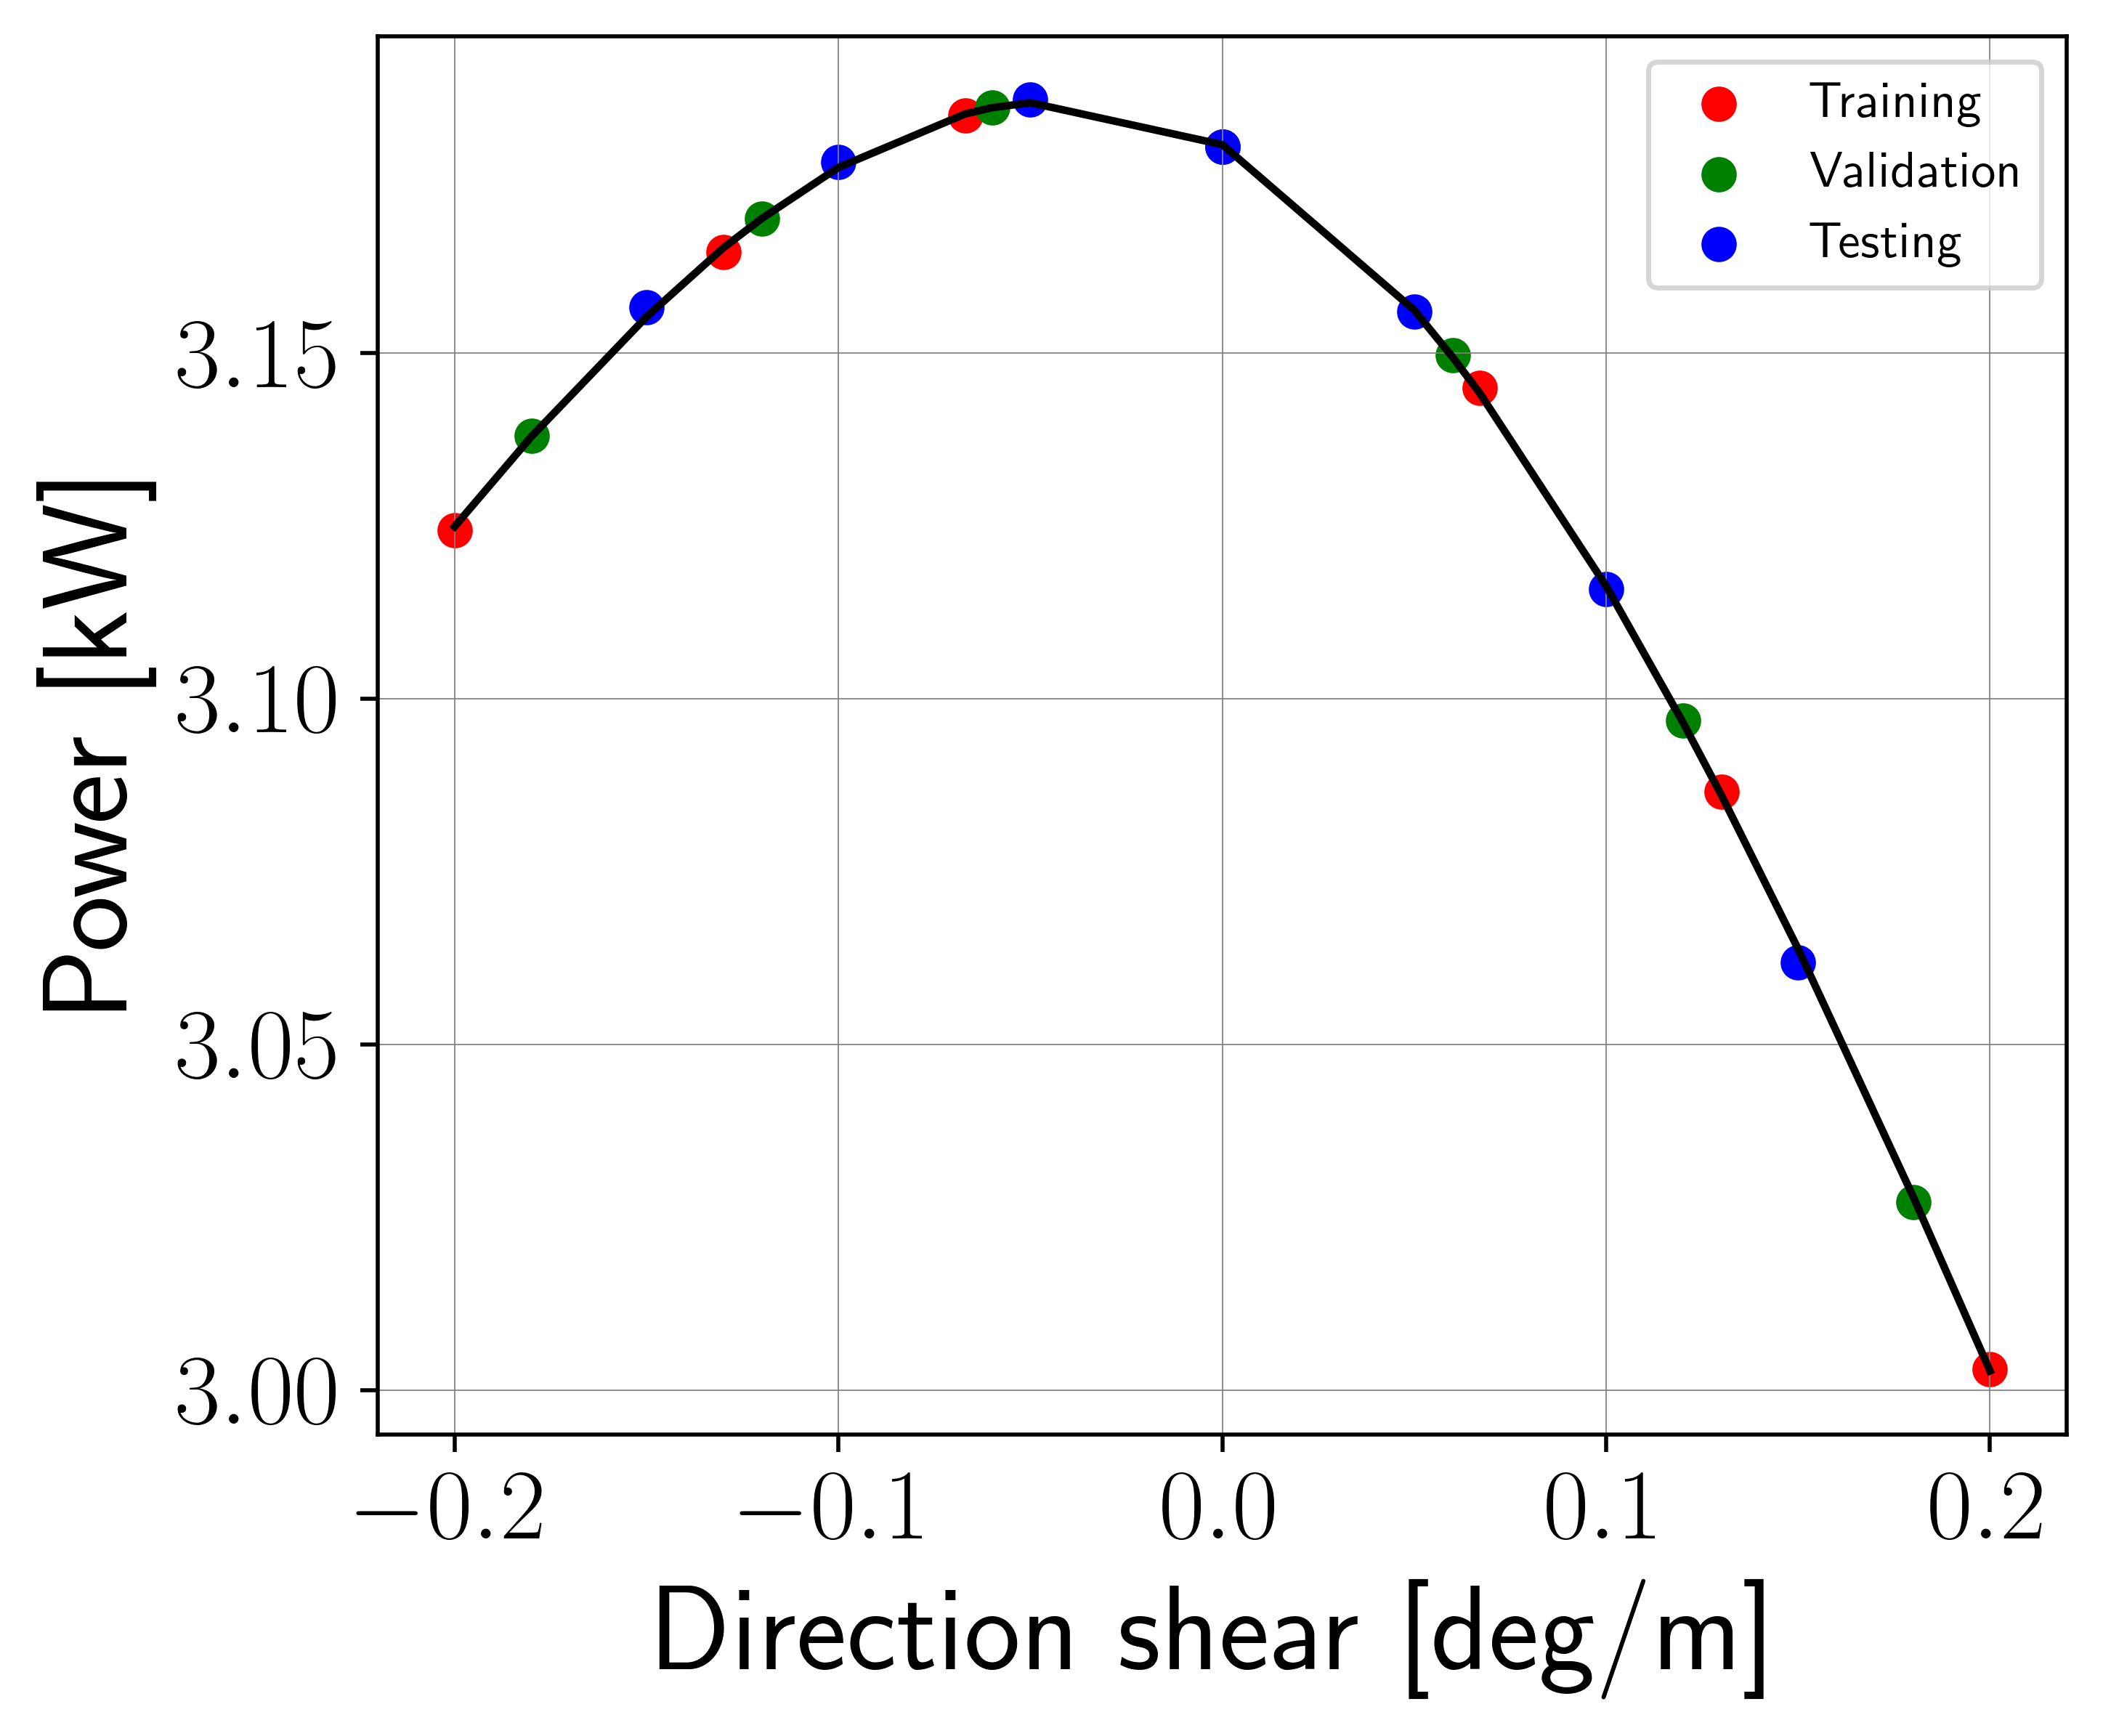

In [164]:
# ROTOR AVERAGE
fig, ax = plt.subplots(figsize=(6, 5))

# rated = 1
# rated = gpr_tr_pow[3]

# ax.plot(veers_tr, gpr_tr_pow/rated , color='r', label='Training')
# ax.plot(veers_va, gpr_va_pow/rated , color='g', label='Training')
# ax.plot(veers_te, gpr_te_pow/rated , color='b', label='Training')

ax.plot(ref_veers, ref_power, '-k')

ax.scatter(veers_tr, gpr_tr_pow, color='r', label='Training')
ax.scatter(veers_va, gpr_va_pow, color='g', label='Validation')
ax.scatter(veers_te, gpr_te_pow, color='b', label='Testing')

# ax.scatter(veers_tr, gpr_tr_pow/gpr_tr_pow[3] , color='r', label='Training')
# ax.scatter(veers_va, gpr_va_pow/gpr_va_pow[3] , color='g', label='Validation')
# ax.scatter(veers_te, gpr_te_pow/gpr_te_pow[3] , color='b', label='Testing')



# ax.plot(veers_va, base_les_va_pow, '-k')
# ax.scatter(veers_va, gpr_va_pow, color='g', label='Validation')

# ax.plot(veers_te, base_les_te_pow, '-r')
# ax.scatter(veers_te, gpr_te_pow, color='r', label='Test')

# ax.plot(veers_tr, base_les_tr_pow, '-g')
# ax.scatter(veers_tr, gpr_tr_pow, color='g', label='Train')

ax.legend(fontsize=10)

ax.set_ylabel('Power [kW]',fontsize=fontsize)
# ax.set_ylabel('P/P_0 [-]',fontsize=fontsize)
ax.set_xlabel('Direction shear [deg/m]',fontsize=fontsize)

# ax.set_ylim([3.2,3.55])

# ax.set_yscale('log')

# tick_positions = [0,1,2,3,4,5,6]  # indices along the x-axis
# tick_labels = ['$-0.2$', '$-0.1$', '$-0.05$', '$0$', '$0.05$', '$0.1$', '$0.2$']
# ax.set_xticks(tick_positions)
# ax.set_xticklabels(tick_labels, rotation=45, fontsize=fontsize)

ax.grid(True,color = "grey", linewidth = "0.25")